# Residual Diagnostics for Linear Models

## Overview

Regression diagnostics check whether the assumptions underlying a linear model are satisfied. Violated assumptions invalidate inference — p-values, confidence intervals, and predictions may all be wrong even when coefficient estimates look reasonable.

**Linear model assumptions (LINE):**

| Assumption | What to check | Diagnostic |
|---|---|---|
| **L**inearity | Residuals vs. fitted; partial residual plots | Curved pattern = non-linear relationship |
| **I**ndependence | Residuals vs. order/time/space | Autocorrelation structure |
| **N**ormality | Q-Q plot of residuals | Deviations from diagonal |
| **E**qual variance | Scale-location plot | Fanning or funnel pattern |

Additionally: **influential observations** (leverage × residual) can unduly control the fitted line.

**Key distinction:** Normality of residuals matters for inference (p-values, CIs), not for coefficient estimation (OLS is unbiased regardless). With large n, the CLT makes inference robust to mild non-normality. Equal variance (homoskedasticity) matters more — heteroskedasticity inflates standard errors unevenly across the predictor range.

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(broom)         # augment(), tidy(), glance()
library(ggfortify)     # autoplot() for lm objects
library(car)           # ncvTest(), vif(), influencePlot()
library(lmtest)        # bptest() Breusch-Pagan, dwtest() Durbin-Watson
library(patchwork)

set.seed(42)

n <- 180
diag_data <- tibble(
  nitrate    = runif(n, 1, 12),
  water_qual = 10 - 0.6*nitrate + rnorm(n, 0, 1.2),
  elevation  = rnorm(n, 200, 80),
  richness   = round(25 - 1.8*nitrate + 0.8*water_qual +
                     0.01*elevation + rnorm(n, 0, 2.5))
)

lm_fit <- lm(richness ~ nitrate + water_qual + elevation, data=diag_data)
summary(lm_fit)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'broom' was built under R version 4.4.3"
Warning message:
"package 'ggfortify' was built under R version 4.


Call:
lm(formula = richness ~ nitrate + water_qual + elevation, data = diag_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-6.3271 -1.6236 -0.1297  1.8441  8.4801 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 23.559452   1.895381  12.430  < 2e-16 ***
nitrate     -1.654136   0.121364 -13.630  < 2e-16 ***
water_qual   0.909814   0.174578   5.211  5.2e-07 ***
elevation    0.008833   0.002636   3.351 0.000987 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2.646 on 176 degrees of freedom
Multiple R-squared:  0.8783,	Adjusted R-squared:  0.8762 
F-statistic: 423.3 on 3 and 176 DF,  p-value: < 2.2e-16


---

## The Four Standard Diagnostic Plots

Warning message:
"`fortify(<lm>)` was deprecated in ggplot2 4.0.0.
ℹ Please use `broom::augment(<lm>)` instead.
ℹ The deprecated feature was likely used in the ggfortify package.
  Please report the issue at <https://github.com/sinhrks/ggfortify/issues>."
Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the ggfortify package.
  Please report the issue at <https://github.com/sinhrks/ggfortify/issues>."
Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ggfortify package.
  Please report the issue at <https://github.com/sinhrks/ggfortify/issues>."



Plot 1 — Residuals vs. Fitted:
  GOOD: points randomly scattered around zero; red line approximately horizontal
  BAD:  curved pattern (non-linearity); funnel shape (heteroskedasticity)

Plot 2 — Normal Q-Q:
  GOOD: points follow the diagonal line
  BAD:  S-curve (skewness); heavy tails (kurtosis); outlier points far from line

Plot 3 — Scale-Location:
  GOOD: points randomly scattered; red line approximately horizontal
  BAD:  upward trend = variance increases with fitted values (right-skewed residuals)

Plot 4 — Residuals vs. Leverage:
  GOOD: most points inside Cook's distance contours
  BAD:  points outside dashed Cook's lines = high influence; may warrant investigation


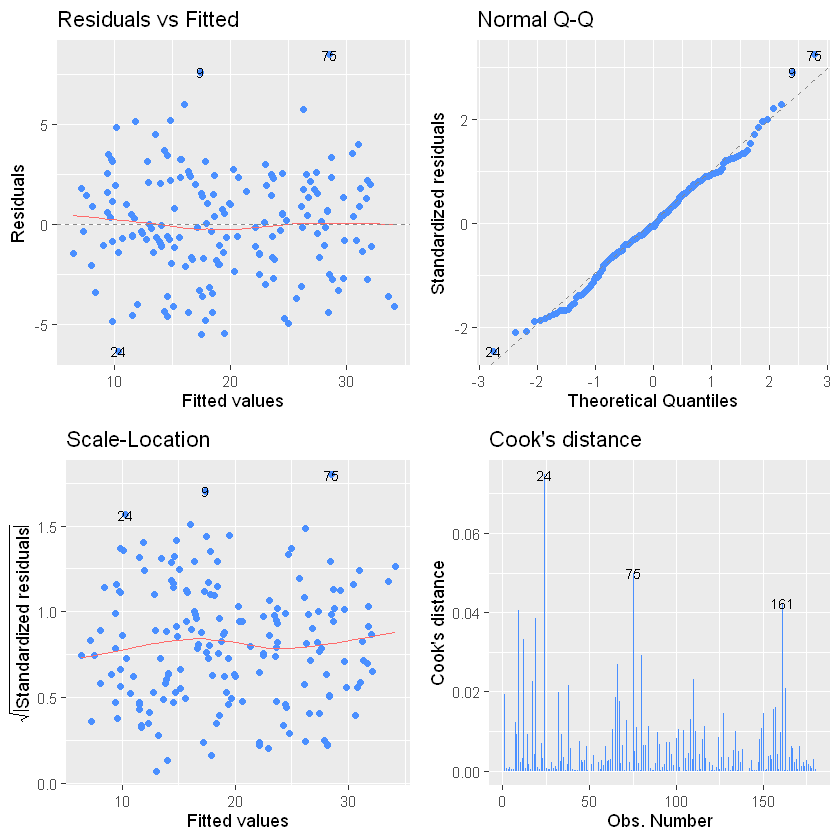

In [3]:
# Load ggfortify to register the S3 autoplot method for lm objects
library(ggfortify)

# Call autoplot via ggplot2, not ggfortify::
ggplot2::autoplot(
  lm_fit,
  which         = 1:4,
  ncol          = 2,
  colour        = "#4a8fff",
  smooth.colour = "#ff6b6b",
  label.size    = 3
) +
  patchwork::plot_annotation(
    title    = "Linear Model Diagnostic Plots",
    subtitle = "Top-left: linearity | Top-right: normality | Bottom-left: homoskedasticity | Bottom-right: influence"
  )

# ── Interpretation guide ──────────────────────────────────────────────────────
cat("
Plot 1 — Residuals vs. Fitted:
  GOOD: points randomly scattered around zero; red line approximately horizontal
  BAD:  curved pattern (non-linearity); funnel shape (heteroskedasticity)

Plot 2 — Normal Q-Q:
  GOOD: points follow the diagonal line
  BAD:  S-curve (skewness); heavy tails (kurtosis); outlier points far from line

Plot 3 — Scale-Location:
  GOOD: points randomly scattered; red line approximately horizontal
  BAD:  upward trend = variance increases with fitted values (right-skewed residuals)

Plot 4 — Residuals vs. Leverage:
  GOOD: most points inside Cook's distance contours
  BAD:  points outside dashed Cook's lines = high influence; may warrant investigation
")

---

## Formal Tests

In [4]:
aug <- broom::augment(lm_fit)

# ── Normality: Shapiro-Wilk (best for n < 5000) ───────────────────────────────
sw <- shapiro.test(aug$.resid)
cat(sprintf("Shapiro-Wilk normality: W=%.4f, p=%.4f%s\n",
            sw$statistic, sw$p.value,
            ifelse(sw$p.value < 0.05, " ← significant departure", " ← no evidence against normality")))

# ── Heteroskedasticity: Breusch-Pagan ─────────────────────────────────────────
bp <- lmtest::bptest(lm_fit)
cat(sprintf("Breusch-Pagan: χ²=%.3f, df=%d, p=%.4f%s\n",
            bp$statistic, bp$parameter, bp$p.value,
            ifelse(bp$p.value < 0.05, " ← significant heteroskedasticity", " ← no evidence of heteroskedasticity")))

# ── Autocorrelation: Durbin-Watson (for time-ordered data) ───────────────────
dw <- lmtest::dwtest(lm_fit)
cat(sprintf("Durbin-Watson: DW=%.4f, p=%.4f%s\n",
            dw$statistic, dw$p.value,
            ifelse(dw$p.value < 0.05, " ← significant autocorrelation", " ← no evidence of autocorrelation")))
# DW near 2 = no autocorrelation; near 0 = positive; near 4 = negative

# ── Non-constant variance: ncvTest (Score test) ───────────────────────────────
ncv <- car::ncvTest(lm_fit)
cat(sprintf("NCV Score test: χ²=%.3f, df=%d, p=%.4f\n",
            ncv$ChiSquare, ncv$Df, ncv$p))

Shapiro-Wilk normality: W=0.9909, p=0.3147 ← no evidence against normality
Breusch-Pagan: χ²=2.830, df=3, p=0.4186 ← no evidence of heteroskedasticity
Durbin-Watson: DW=1.9291, p=0.3169 ← no evidence of autocorrelation
NCV Score test: χ²=0.011, df=1, p=0.9180


---

## Partial Residual Plots

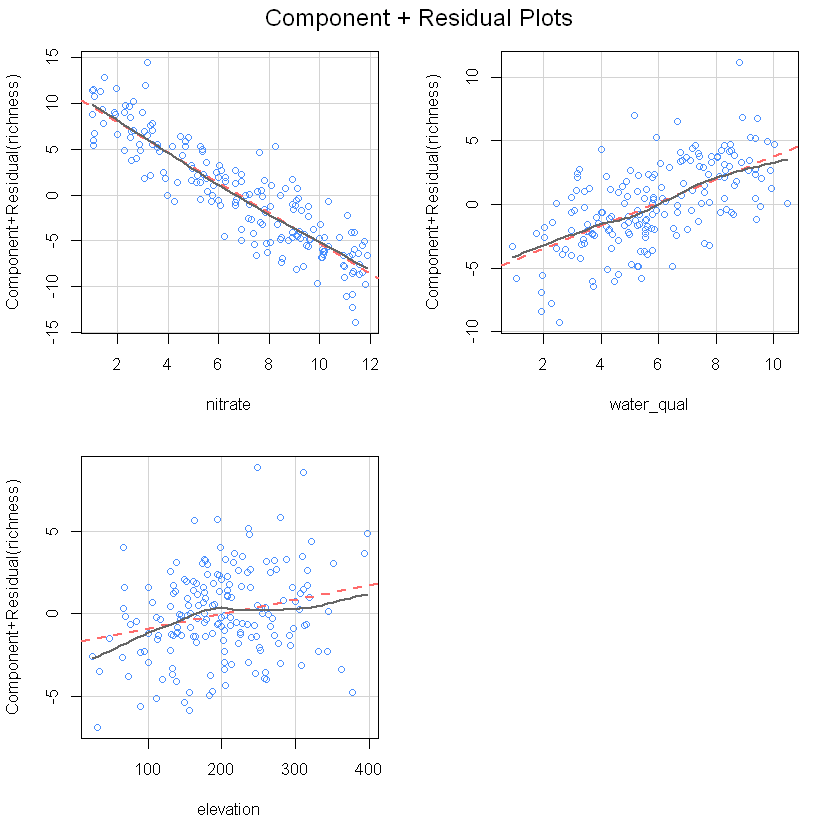

In [5]:
# Component + Residual (partial residual) plots
# Show the marginal relationship between each predictor and the response
# after accounting for all other predictors
# Non-linear pattern = missing non-linear term (polynomial, spline)

car::crPlots(
  lm_fit,
  smooth    = TRUE,
  col       = "#4a8fff",
  col.lines = c("#ff6b6b", "gray40"),
  main      = "Component + Residual Plots"
)
# Red line = smoothed partial residuals; blue line = linear term
# If they diverge substantially → non-linearity in that predictor

---

## Handling Heteroskedasticity: Robust Standard Errors

In [6]:
library(sandwich)   # vcovHC() — heteroskedasticity-consistent covariance
library(lmtest)     # coeftest()

# HC3 robust standard errors (recommended for small–moderate n)
robust_se <- lmtest::coeftest(
  lm_fit,
  vcov = sandwich::vcovHC(lm_fit, type="HC3")
)

# Compare OLS vs. robust SEs
comparison <- bind_rows(
  broom::tidy(lm_fit) %>% mutate(se_type="OLS"),
  broom::tidy(robust_se) %>% mutate(se_type="HC3 Robust")
) %>%
  filter(term != "(Intercept)") %>%
  select(se_type, term, estimate, std.error, p.value) %>%
  mutate(across(where(is.numeric), ~round(.x, 4)))

print(comparison)
# If SEs differ substantially: OLS inference is unreliable; report robust SEs
# Estimates are identical — only standard errors (and thus p-values) change

# A tibble: 6 × 5
  se_type    term       estimate std.error p.value
  <chr>      <chr>         <dbl>     <dbl>   <dbl>
1 OLS        nitrate     -1.65      0.121   0     
2 OLS        water_qual   0.910     0.175   0     
3 OLS        elevation    0.0088    0.0026  0.001 
4 HC3 Robust nitrate     -1.65      0.111   0     
5 HC3 Robust water_qual   0.910     0.164   0     
6 HC3 Robust elevation    0.0088    0.003   0.0032


---

## Common Pitfalls

**1. Relying solely on formal tests for assumption checking**  
The Shapiro-Wilk test has low power in small samples (may miss real non-normality) and near-certain rejection in large samples (flags trivially small departures). Always inspect the Q-Q plot visually and use formal tests as supporting evidence. The visual assessment is more informative about the nature and severity of any violation.

**2. Transforming the response to fix non-normality instead of heteroskedasticity**  
Log-transforming the response is often recommended for non-normal residuals. But if the true problem is heteroskedasticity — variance proportional to the mean — the log transform fixes both simultaneously. If the problem is only skewed residuals with constant variance, a log transform changes the model's mean function and complicates interpretation. Diagnose which assumption is violated before choosing the remedy.

**3. Ignoring partial residual plots when the global residual plot looks fine**  
A residual vs. fitted plot can look approximately flat even when individual predictors have non-linear relationships, because non-linearities from different predictors cancel out. Always inspect component-plus-residual plots for each predictor separately.

**4. Treating Durbin-Watson as a general autocorrelation test**  
Durbin-Watson only detects first-order autocorrelation (lag-1). For spatial data or higher-order temporal autocorrelation, use a variogram or ACF/PACF of residuals instead.

**5. Applying linear model diagnostics to GLMs without adjustment**  
Raw residuals from GLMs (logistic, Poisson) are not expected to be normal or have constant variance — these are features of the error distribution, not violations. Use Pearson or deviance residuals for GLMs, and DHARMa simulation-based residuals for GLMMs. See `dharma_diagnostics.ipynb`.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*